In [42]:
import warnings
warnings.filterwarnings('ignore')

In [43]:
import pandas as pd
import numpy as np
import pyreadr
import joblib
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [44]:
pd.set_option('display.max_columns', 100)

In [45]:
dem_uncont = 34
rep_uncont = 31

In [46]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont)
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims

,seats,winner
0,54,Democrats
1,55,Democrats
2,48,Republicans
3,54,Democrats
4,48,Republicans
...,...,...
7995,51,Democrats
7996,52,Democrats
7997,53,Democrats
7998,51,Democrats


In [47]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 51 else (100-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,37,1,0.0125,Republicans
1,38,1,0.0125,Republicans
2,41,5,0.0625,Republicans
3,42,13,0.1625,Republicans
4,43,57,0.7125,Republicans


In [48]:
np.unique(seat_sims['seats']).shape[0]

25

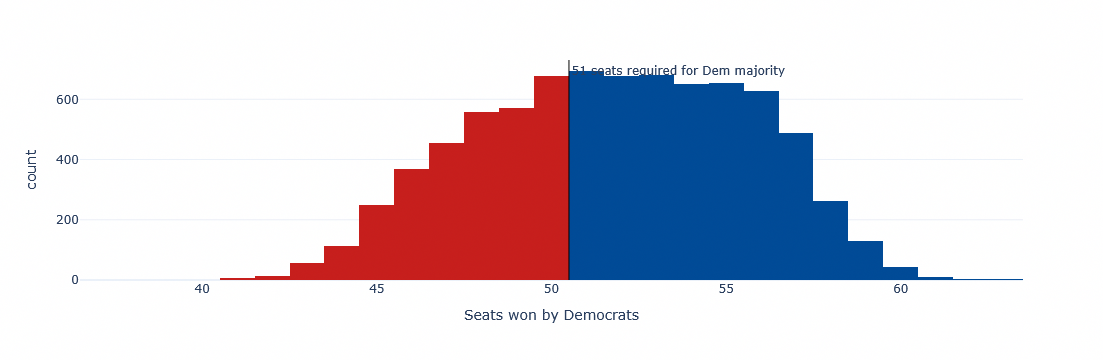

In [49]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=50.5, line_width=1, line_color='black', annotation_text='51 seats required for Dem majority', 
                    annotation_position='top right')
sims_hist

In [50]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-09-27,51.348375,US Senate,seats
1,2026-09-27,58.600000,US Senate,chance
2,2026-09-27,3.816193,US Senate,seats_sd
3,2026-09-27,38.771876,AL,y_pred
4,2026-09-27,3.537242,AL,y_pred_sd


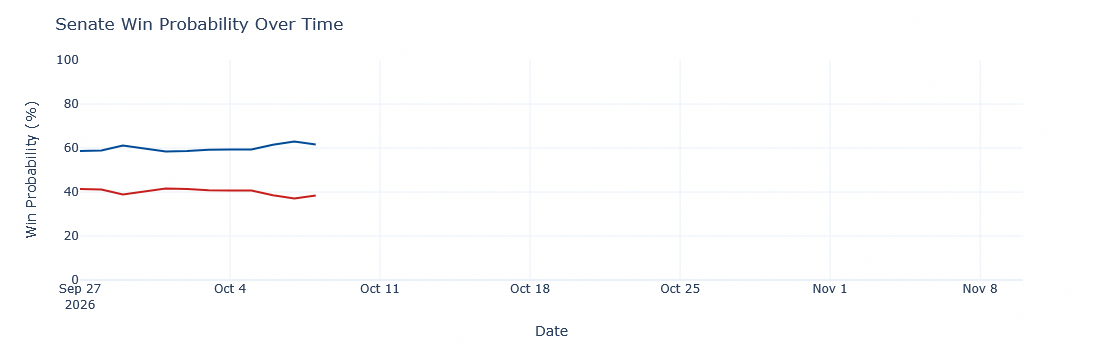

In [51]:
chance_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="Senate Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

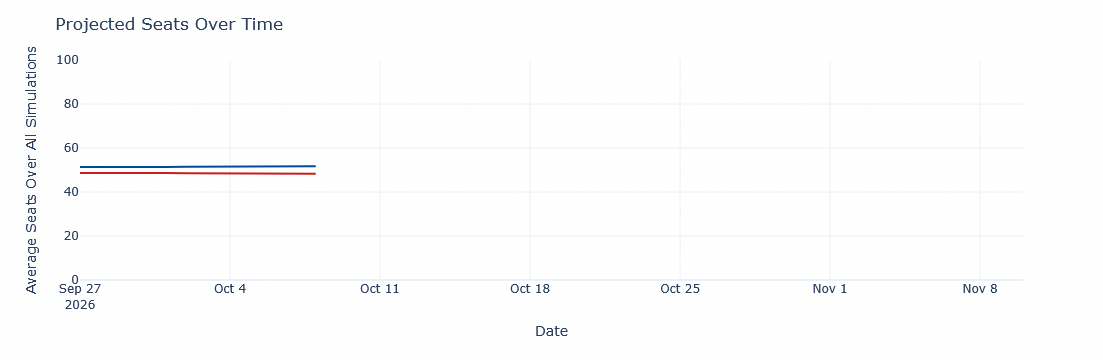

In [52]:
seats_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 100 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [53]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [54]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [55]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,7950,7951,7952,7953,7954,7955,7956,7957,7958,7959,7960,7961,7962,7963,7964,7965,7966,7967,7968,7969,7970,7971,7972,7973,7974,7975,7976,7977,7978,7979,7980,7981,7982,7983,7984,7985,7986,7987,7988,7989,7990,7991,7992,7993,7994,7995,7996,7997,7998,7999
AL,-7.877215,-13.943827,-12.136338,-12.173363,-9.855754,-13.697660,-11.726582,-5.580796,-12.662945,-17.606390,-1.404631,-13.578245,-11.415635,-11.869240,-12.435353,-9.549738,-9.861722,-12.863855,-10.275252,-7.767117,-13.155837,-9.071323,-7.245168,-9.624482,-9.307718,-14.486701,-14.065633,-8.426268,-13.306495,-13.115272,-10.603739,-12.174891,-11.832578,-8.338400,-16.356149,-15.365487,-8.172840,-11.139599,-9.019724,-12.840868,-10.857538,-9.150289,-14.255534,-10.872609,-13.111040,-13.593870,-13.205477,-15.434924,-7.944464,-11.775344,...,-11.916850,-11.213227,-10.361177,-15.405606,-7.616218,-11.736375,-13.304173,-8.177212,-12.654801,-8.495523,-16.507837,-16.541501,-10.846999,-7.542067,-17.749581,-7.403194,-16.658723,-3.375057,-12.623466,-8.877931,-11.906477,-10.258551,-4.638995,-21.842461,-3.289648,-14.701486,-12.234278,-13.560085,-8.537152,-12.615265,-11.198073,-12.889752,-11.287762,-8.291191,-16.979554,-12.801099,-11.408489,-19.020447,-10.658486,-10.167689,-11.010914,-14.583981,-10.800660,-10.700984,-12.471555,-13.540388,-15.164542,-10.272220,-12.963492,-12.487421
AK,0.688791,5.848062,0.087553,5.763196,-0.721514,4.833585,5.249388,5.570870,-0.333286,-5.408698,11.096072,0.543007,-0.911485,6.677981,-0.561535,3.422487,5.918782,4.935378,-0.159973,3.045401,7.042671,4.482823,2.569066,5.273501,4.958543,1.738177,2.680617,3.742993,-0.719535,1.921164,3.730194,5.919212,7.215542,8.489720,3.107279,0.088214,3.780124,0.344646,-0.808960,3.457042,-0.969681,3.818517,7.177592,4.358117,2.823999,-1.451184,1.141641,3.195826,2.491284,4.542182,...,4.191336,3.172196,10.219004,-0.208885,7.753620,2.983921,1.355267,3.751819,-1.244291,10.664487,2.556761,-0.714255,7.198475,3.463104,4.022530,1.745358,5.139385,2.269807,-0.519319,7.705111,1.776707,3.471322,8.767838,0.261290,4.308804,-2.309413,6.434409,5.230566,3.666331,1.185867,-3.018448,5.549157,-0.626470,6.110390,2.012931,3.167314,3.410168,7.474892,4.178818,4.174496,0.302001,4.454202,4.031282,0.586764,4.277319,0.920540,1.889589,0.729014,3.789730,1.889952
AR,-11.309862,-13.059671,-9.446180,-12.117492,-10.905453,-9.121029,-10.153383,-6.700225,-15.350585,-15.050568,-2.300726,-12.826634,-13.695785,-8.191943,-13.173095,-11.814760,-11.149534,-9.656947,-12.028340,-8.363655,-12.347009,-11.785741,-8.126547,-8.289072,-12.537416,-9.939485,-12.368060,-9.016251,-12.355990,-12.122550,-9.487616,-10.225866,-7.628415,-8.385950,-14.570193,-14.033614,-7.298769,-10.840975,-12.358795,-11.436791,-11.491248,-7.371036,-13.157097,-15.010356,-13.653316,-11.848273,-9.971584,-14.954047,-11.860253,-12.806546,...,-13.847643,-12.487820,-9.126730,-14.463242,-4.861755,-13.315335,-13.684163,-12.418952,-11.276327,-4.972377,-15.620288,-13.204622,-9.227027,-8.573764,-14.510957,-5.706152,-16.468141,-2.181402,-10.321992,-9.580669,-12.872387,-7.376902,-5.890614,-16.508453,-4.353155,-17.499358,-10.156699,-17.170308,-6.308801,-10.760416,-10.178729,-11.891741,-10.619602,-3.472200,-18.543112,-10.644941,-8.675688,-13.427801,-7.068472,-13.103205,-12.154357,-11.719042,-9.603230,-8.161276,-12.321393,-14.342996,-17.982634,-12.275935,-8.723955,-11.798926
CO,11.603984,12.384743,7.458018,14.310056,9.064779,12.746506,14.550180,13.440394,11.015976,7.340552,13.509208,13.995981,11.112348,16.375831,8.124788,15.856093,13.913956,11.997895,7.009362,6.276469,13.136180,18.892624,10.098944,16.635178,13.887038,11.681433,11.507445,20.257760,7.924330,13.720260,14.279640,10.661144,9.577789,10.683623,11.963342,6.010962,16.517724,11.406492,15.622429,9.408952,13.252024,12.231886,11.864039,13.802335,10.798729,11.935592,7.852508,11.317099,12.594650,9.738585,...,14.011627,8.842272,17.614751,10.

In [56]:
sim_corr = post_untransp.corr()

In [57]:
sim_corr.head()

,AL,AK,AR,CO,DE,FL,GA,ID,IL,IA,KS,KY,LA,ME,MA,MI,MN,MS,MT,NE,NH,NJ,NM,NC,OH,OK,OR,RI,SC,SD,TN,TX,VA,WV,WY
AL,1.000000,0.516535,0.740087,0.490238,0.497264,0.706438,0.532006,0.737235,0.706078,0.744241,0.737840,0.541086,0.751806,0.736267,0.523349,0.734652,0.708824,0.743856,0.702485,0.725122,0.503029,0.506888,0.506558,0.705624,0.506881,0.758508,0.507788,0.490948,0.491701,0.512045,0.557547,0.702047,0.506610,0.741290,0.739083
AK,0.516535,1.000000,0.516675,0.520779,0.524752,0.498860,0.558210,0.526738,0.505219,0.517780,0.519115,0.566224,0.523679,0.505777,0.560495,0.511162,0.499447,0.516849,0.498722,0.516503,0.561888,0.538956,0.554180,0.498163,0.553236,0.520823,0.547006,0.549469,0.538228,0.541624,0.597617,0.508722,0.544047,0.520454,0.519393
AR,0.740087,0.516675,1.000000,0.487475,0.499993,0.703564,0.527896,0.736374,0.699084,0.741387,0.737555,0.537147,0.742280,0.729964,0.523849,0.728967,0.700715,0.725885,0.694491,0.721505,0.509078,0.500464,0.501687,0.705663,0.504462,0.744301,0.501836,0.497114,0.495481,0.515396,0.557066,0.701823,0.498886,0.735953,0.735067
CO,0.490238,0.520779,0.487475,1.000000,0.708957,0.653460,0.550517,0.497626,0.653028,0.503228,0.487131,0.549398,0.503921,0.483918,0.538148,0.486971,0.643044,0.493869,0.653942,0.477437,0.710166,0.715797,0.719445,0.647643,0.704414,0.499901,0.710493,0.702491,0.699070,0.530818,0.571433,0.656002,0.703963,0.496865,0.494062
DE,0.497264,0.524752,0.499993,0.708957,1.000000,0.667341,0.543064,0.504101,0.663988,0.508837,0.499864,0.547761,0.503500,0.500399,0.549131,0.501308,0.663499,0.499232,0.665059,0.489332,0.718686,0.725939,0.728406,0.661479,0.714905,0.515673,0.710041,0.712865,0.709292,0.521156,0.577949,0.661456,0.719022,0.499431,0.509316


In [58]:
post.shape

(35, 8000)

In [59]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 51 - dem_uncont: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (51 - dem_uncont)
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (100 - seats_won_dem - dem_uncont - rep_uncont) - (50 - rep_uncont)
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [60]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:06<00:00, 1170.60it/s]


array(['IA', 'FL', 'TX', ..., 'IA', 'MA', 'AK'],
      shape=(8000,), dtype='<U32')

In [61]:
data = pd.read_csv('../../model_output/senate_predictions.csv')
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.524581,53.994266,0.524581,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.524581,0.724280,20.995085,-20.380443,-49.622498,0,-99.244996,38.704281,3.539884,0.0500,1,31.894588,45.774841
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.365832,48.295887,3.365832,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,3.365832,1.834620,-1.833614,-3.664605,49.948144,-1,99.896288,53.367931,3.406785,83.8500,2,46.690813,60.201372
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.331448,49.190029,0.331448,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.331448,0.575715,11.000508,-21.375044,-8.541719,-1,-17.083438,39.141913,3.567870,0.1250,3,32.042101,46.042226
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.175135,47.730058,1,95.460117,61.957507,3.504049,99.9625,4,55.169436,68.862074
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.268388,48.524126,1,97.048252,63.500733,3.504492,99.9875,5,56.661193,70.458049


In [62]:
data['tipping_point_prob'] = data['state_po'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.524581,53.994266,0.524581,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.524581,0.724280,20.995085,-20.380443,-49.622498,0,-99.244996,38.704281,3.539884,0.0500,1,31.894588,45.774841,0.0000
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.365832,48.295887,3.365832,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,3.365832,1.834620,-1.833614,-3.664605,49.948144,-1,99.896288,53.367931,3.406785,83.8500,2,46.690813,60.201372,4.6125
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.331448,49.190029,0.331448,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.331448,0.575715,11.000508,-21.375044,-8.541719,-1,-17.083438,39.141913,3.567870,0.1250,3,32.042101,46.042226,0.0000
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.175135,47.730058,1,95.460117,61.957507,3.504049,99.9625,4,55.169436,68.862074,0.1250
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.268388,48.524126,1,97.048252,63.500733,3.504492,99.9875,5,56.661193,70.458049,0.4375


In [63]:
data.sort_values('tipping_point_prob', ascending=False).head(5)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
31,31,Texas,James Talarico,Ken Paxton,False,False,R,TX,"TALARICO, JAMES","PAXTON, WARREN KENNETH JR.",65585741.88,9020177.98,74605919.86,87.909568,12.090432,-5.916874,43.060966,48.286718,4.530331,31.642337,13.173480,0.180615,33.823334,24400697,4744808,29145505,83.720275,16.279725,0.987401,-9.245999,0,0,48.400199,7.478251,44.988082,7.478251,West South Central,2026,0.0,0.25284,-0.25284,6,Senate,7728.092153,7.478251,2.734639,-3.412117,-2.587749,37.909568,0,75.819136,51.477068,3.629900,66.0750,32,44.399521,58.693462,10.5250
9,9,Iowa,Josh Turek,Ashley Hinson,False,False,R,IA,"TUREK, JOSHUA","ARENHOLZ, ASHLEY HINSON",5835816.67,5267628.55,11103445.22,52.558612,47.441388,-6.092833,43.277201,88.847514,1.696738,4.401391,3.028533,0.168574,31.423453,2014831,1175538,3190369,63.153541,36.846459,0.987401,-9.245999,0,0,46.777297,6.467985,45.241396,6.467985,West North Central,2026,0.0,0.00000,0.00000,3,Senate,2762.407675,6.467985,2.543223,-1.535901,-2.939667,2.558612,0,5.117224,50.304798,3.516393,52.8625,10,43.308138,57.200507,10.3375
15,15,Michigan,Abdul El-Sayed,Mike J. Rogers,False,False,D,MI,"EL-SAYED, ABDUL","ROGERS, MICHAEL J",14408058.06,6831818.66,21239876.72,67.834942,32.165058,-0.192456,49.278763,77.709102,2.333008,4.148895,12.968600,0.319413,32.445883,7404258,2673073,10077331,73.474395,26.525605,0.987401,-9.245999,0,0,48.150050,9.375726,45.801667,9.375726,East North Central,2026,0.0,0.00000,0.00000,2,Senate,4601.579360,9.375726,3.061981,-2.348383,8.861087,17.834942,0,35.669884,50.330854,3.539957,53.6875,16,43.547879,57.346240,10.1125
24,24,Ohio,Sherrod Brown,Jon Husted,False,True,R,OH,"BROWN, SHERROD","HUSTED, JON",31146133.40,6280012.05,37426145.45,83.220254,16.779746,-5.266554,44.343385,80.925356,1.708882,3.291326,11.486903,0.076606,31.487184,9001099,2798349,11799448,76.284069,23.715931,0.987401,-9.245999,0,1,47.551734,4.515168,45.022536,4.515168,East North Central,2026,0.0,0.00000,0.00000,2,Senate,6925.610718,4.515168,2.124892,-2.529198,-1.287108,33.220254,-1,66.440509,50.812501,3.471369,59.1125,25,43.924904,57.689502,8.8000
13,13,Maine,Troy Jackson,Susan Collins,False,True,R,ME,no_match,"COLLINS, SUSAN M.",0.00,10501136.60,10501136.60,0.000000,100.000000,3.820912,53.544306,94.249770,0.897865,1.689465,0.930085,0.342309,36.189622,526309,836050,1362359,38.632181,61.367819,0.987401,-9.245999,0,1,48.626272,6.774790,47.537172,6.774790,New England,2026,0.0,0.00000,0.00000,3,Senate,0.000000,6.774790,2.602843,-1.089100,16.887824,-50.000000,-1,-100.000000,49.532361,3.595193,44.5625,14,42.413038,56.618903,7.9875


In [64]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Dan Osborn', 'Brian Bengs', 'Todd Achilles', 'Seth Bodnar']
    indie_r = []
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [65]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.524581,53.994266,0.524581,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.524581,0.724280,20.995085,-20.380443,-49.622498,0,-99.244996,38.704281,3.539884,0.0500,1,31.894588,45.774841,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b..."
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.365832,48.295887,3.365832,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,3.365832,1.834620,-1.833614,-3.664605,49.948144,-1,99.896288,53.367931,3.406785,83.8500,2,46.690813,60.201372,4.6125,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>..."
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.331448,49.190029,0.331448,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.331448,0.575715,11.000508,-21.375044,-8.541719,-1,-17.083438,39.141913,3.567870,0.1250,3,32.042101,46.042226,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<..."
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,21.175135,47.730058,1,95.460117,61.957507,3.504049,99.9625,4,55.169436,68.862074,0.1250,Safe D,"<b style=""color:#366bbf;"">John Hickenlooper* (..."
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-9.245999,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,25.268388,48.524126,1,97.048252,63.500733,3.504492,99.9875,5,56.661193,70.458049,0.4375,Safe D,"<b style=""color:#366bbf;"">Chris Coons* (D)</b>..."


In [66]:
data['projected_winner'] = data['chance'].map(lambda x: 'D' if x > 50 else 'R')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.524581,53.994266,0.524581,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.524581,0.724280,20.995085,-20.380443,-49.622498,0,-99.244996,38.704281,3.539884,0.050,1,31.894588,45.774841,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.365832,48.295887,3.365832,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.365832,1.834620,-1.833614,-3.664605,49.948144,-1,99.896288,53.367931,3.406785,83.850,2,46.690813,60.201372,4.6125,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.331448,49.190029,0.331448,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.331448,0.575715,11.000508,-21.375044,-8.541719,-1,-17.083438,39.141913,3.567870,0.125,3,32.042101,46.042226,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R


In [67]:
data['hold'] = data['projected_winner'] ==  data['current_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.524581,53.994266,0.524581,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.524581,0.72428,20.995085,-20.380443,-49.622498,0,-99.244996,38.704281,3.539884,0.05,1,31.894588,45.774841,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.365832,48.295887,3.365832,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.365832,1.83462,-1.833614,-3.664605,49.948144,-1,99.896288,53.367931,3.406785,83.85,2,46.690813,60.201372,4.6125,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip


In [68]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.524581,53.994266,0.524581,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.524581,0.724280,20.995085,-20.380443,-49.622498,0,-99.244996,38.704281,3.539884,0.050,1,31.894588,45.774841,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.365832,48.295887,3.365832,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.365832,1.834620,-1.833614,-3.664605,49.948144,-1,99.896288,53.367931,3.406785,83.850,2,46.690813,60.201372,4.6125,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.7
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.331448,49.190029,0.331448,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.331448,0.575715,11.000508,-21.375044,-8.541719,-1,-17.083438,39.141913,3.567870,0.125,3,32.042101,46.042226,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.7


In [69]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.524581,53.994266,0.524581,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.524581,0.724280,20.995085,-20.380443,-49.622498,0,-99.244996,38.704281,3.539884,0.050,1,31.894588,45.774841,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6,99.950,0.0,100.0,<1%,>99%
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.365832,48.295887,3.365832,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.365832,1.834620,-1.833614,-3.664605,49.948144,-1,99.896288,53.367931,3.406785,83.850,2,46.690813,60.201372,4.6125,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.7,16.150,83.9,16.1,83.9%,16.1%
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.331448,49.190029,0.331448,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.331448,0.575715,11.000508,-21.375044,-8.541719,-1,-17.083438,39.141913,3.567870,0.125,3,32.042101,46.042226,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.7,99.875,0.1,99.9,<1%,>99%


In [70]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.524581,53.994266,0.524581,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.524581,0.724280,20.995085,-20.380443,-49.622498,0,-99.244996,38.704281,3.539884,0.050,1,31.894588,45.774841,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6,99.950,0.0,100.0,<1%,>99%,8.289785
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.365832,48.295887,3.365832,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.365832,1.834620,-1.833614,-3.664605,49.948144,-1,99.896288,53.367931,3.406785,83.850,2,46.690813,60.201372,4.6125,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.7,16.150,83.9,16.1,83.9%,16.1%,20.428987
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-9.245999,0,1,38.189521,0.331448,49.190029,0.331448,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.331448,0.575715,11.000508,-21.375044,-8.541719,-1,-17.083438,39.141913,3.567870,0.125,3,32.042101,46.042226,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.7,99.875,0.1,99.9,<1%,>99%,9.623812


In [71]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-9.245999,0,0,32.999181,0.524581,53.994266,0.524581,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.524581,0.72428,20.995085,-20.380443,-49.622498,0,-99.244996,38.704281,3.539884,0.05,1,31.894588,45.774841,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.6,99.95,0.0,100.0,<1%,>99%,8.289785,D+8.3
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-9.245999,0,1,50.129501,3.365832,48.295887,3.365832,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,3.365832,1.83462,-1.833614,-3.664605,49.948144,-1,99.896288,53.367931,3.406785,83.85,2,46.690813,60.201372,4.6125,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+6.7,16.15,83.9,16.1,83.9%,16.1%,20.428987,D+20.4


In [72]:
tab_data = data[['state', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Dan Osborn', 'Brian Bengs', 
                                                                                              'Todd Achilles', 'Seth Bodnar'] else x)
tab_data = tab_data.rename({
    'state': 'State',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,State,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,Alabama,Everett Weiss,Barry Moore,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+22.6,D+8.3,0.0000
1,Alaska,Mary Peltola,Dan S. Sullivan,Likely D,"<p style=""color:blue;"">83.9%</p>","<p style=""color:red;"">16.1%</p>",D+6.7,D+20.4,4.6125
2,Arkansas,Hallie Shoffner,Tom Cotton,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+21.7,D+9.6,0.0000
3,Colorado,John Hickenlooper,Mark Baisley,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+23.9,D+12.6,0.1250
4,Delaware,Chris Coons,Michael Katz,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+27.0,D+12.0,0.4375


In [73]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

6.291862800488515

In [74]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,vars,x
0,means_seats_tot,51.753000
1,chamber_win_chance,61.612500
0,sv_bias,6.291863


In [75]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [76]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 100 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Win Probability,Seat Share
0,Democrats,61.6125,51.753
1,Republicans,38.3875,48.247


In [77]:
incl_cols = ['state', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = data[incl_cols]

In [78]:
rating_ts = output_ts[output_ts['type'] == 'chance']
rating_ts['rating'] = rating_ts['y'].map(get_rating)
rating_ts['date'] = pd.to_datetime(rating_ts['date'])
rating_ts.head()

,date,y,geo,type,rating
1,2026-09-27,58.6000,US Senate,chance,Tossup
5,2026-09-27,0.0500,AL,chance,Safe R
10,2026-09-27,79.8875,AK,chance,Likely D
15,2026-09-27,0.1250,AR,chance,Safe R
20,2026-09-27,99.9625,CO,chance,Safe D


In [79]:
## Alert when there's a rating change
today_date = rating_ts['date'].max()
yesterday = rating_ts[rating_ts['date'] != today_date]['date'].max()

today_ratings = rating_ts[rating_ts['date'] == today_date]
yester_ratings = rating_ts[rating_ts['date'] == yesterday]
compare_df = pd.merge(left=today_ratings, right=yester_ratings, on='geo', how='left', suffixes=['_t', '_y'])
compare_df.head()

,date_t,y_t,geo,type_t,rating_t,date_y,y_y,type_y,rating_y
0,2026-10-08,61.6125,US Senate,chance,Tilt D,2026-10-07,62.9875,chance,Tilt D
1,2026-10-08,0.0500,AL,chance,Safe R,2026-10-07,0.0500,chance,Safe R
2,2026-10-08,83.8500,AK,chance,Likely D,2026-10-07,83.9625,chance,Likely D
3,2026-10-08,0.1250,AR,chance,Safe R,2026-10-07,0.1250,chance,Safe R
4,2026-10-08,99.9625,CO,chance,Safe D,2026-10-07,99.9625,chance,Safe D


In [80]:
## This is the cell that actually alerts when there's a rating change
if any(compare_df['rating_t'] != compare_df['rating_y']):
    changes_df = compare_df[compare_df['rating_t'] != compare_df['rating_y']][['geo', 'rating_y', 'rating_t']]
    print(changes_df)
else:
    print("No rating changes today!")

   geo rating_y rating_t
25  OH   Tilt D   Tossup


In [81]:
if any(compare_df['rating_t'] != compare_df['rating_y']):
    print(changes_df.shape)

(1, 3)


In [82]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')